# Seasonal Agriculture Performance Analysis
# **Major Data Analytics Project**

**Domain**: Agriculture

**Project Theme**: Seasonal Agriculture

**Tools used**: Python, Github, Git, Google colab, Pandas, NumPy, Matplotlib, Seaborn

**Project Goal**: Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

# **1. Problem Statement**
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.
The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.
Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

# **2. Project Objectives**
* Understand the agricultural dataset.
* Clean and preprocess the data.
* Analyze seasonal patterns.
* Perform statistical analysis.
* Study variable relationships.
* Compare seasonal performance.
* Create relevant visualizations.
* Identify key findings.
* Develop insights and recommendations.

# **3. Dataset**
The dataset contains farm-level records covering various seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit, and resource usage.
Dataset file:

```
seasonal_agriculture_performance_dataset.csv
```



In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ModuleNotFoundError: No module named 'pandas'

In [5]:
df=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

NameError: name 'pd' is not defined

# **4. Initial Data Understanding**

In [7]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df .shape[1])

Number of rows: 4000
Number of columns: 28


In [8]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [9]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [11]:
# Numerical Summary Statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [12]:
df.sample(5,random_state=40)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
2936,SF12937,Tamil Nadu,Nashik,Cotton,Zaid,13.56,441.70,27.30,62.00,7.40,6.99,17.20,82.50,57.10,105.50,Rainfed,107.60,8.23,0.67,1.33,18.03,83450,541165,1504604,963439,5300,3.40,26.20
2606,SF12607,Gujarat,Ludhiana,Maize,Rabi,1.51,295.60,23.10,70.80,5.40,6.44,29.00,94.30,62.80,146.60,Flood,157.10,3.60,0.92,3.13,4.73,24087,90538,113932,23394,1284,3.68,34.20
2441,SF12442,Tamil Nadu,Nalgonda,Rice,Rabi,9.82,365.70,22.60,41.60,7.00,5.63,16.00,107.90,27.70,128.50,Drip,235.10,7.22,0.85,0.73,7.17,21167,721561,151767,-569794,12275,0.58,34.70
3415,SF13416,Madhya Pradesh,Guntur,Rice,Rabi,6.37,361.50,23.50,59.60,7.20,6.39,23.20,73.60,66.50,40.00,Drip,183.00,6.36,0.73,2.96,18.86,24284,433206,457996,24790,7989,2.36,27.90
2658,SF12659,Gujarat,Erode,Sugarcane,Rabi,11.52,658.70,21.10,63.60,9.10,6.37,24.00,109.80,62.90,121.60,Drip,191.90,0.50,0.89,78.82,908.01,3464,680514,3145347,2464833,18157,50.01,59.10


In [13]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [14]:
# Catagory summary
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# **5. Data Analysis**
The data analysis involves examining agricultural trends, seasonal patterns, crop performance, resource usage, costs, revenue, and profitability. Statistical methods and visualizations are used to identify relationships, compare different groups, and derive meaningful insights from the dataset.

In [15]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd. DataFrame ({
"Missing_Count": missing,
"Missing_Percentage": missing_percentage.round (2)
})
missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


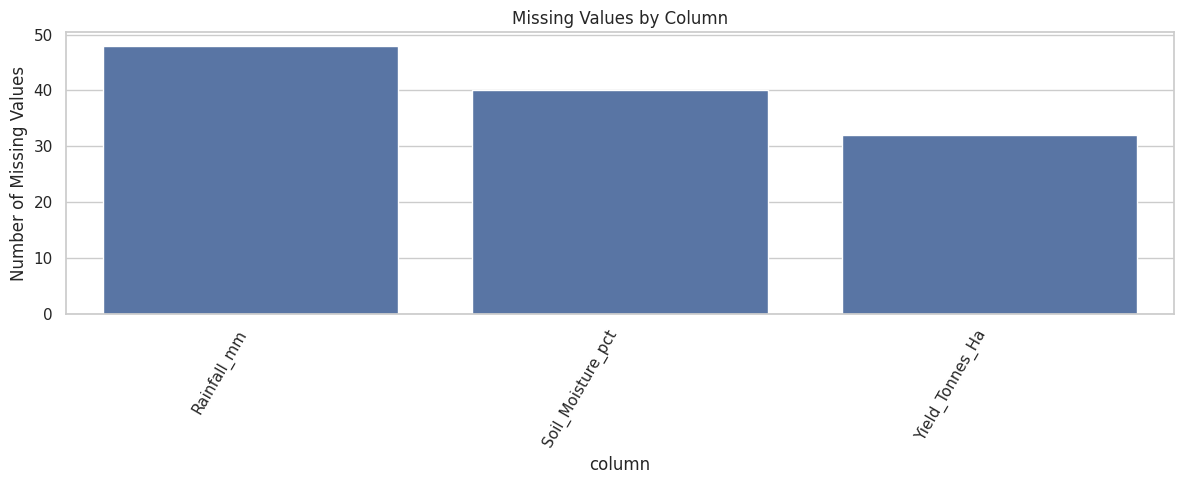

In [16]:
# Visualize missing values
plt. figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
 sns.barplot(x=missing_plot.index, y=missing_plot.values)
 plt.xticks(rotation=60, ha="right")
 plt.ylabel ("Number of Missing Values")
 plt.xlabel ("column")
 plt.title("Missing Values by Column")
 plt.tight_layout()
 plt.show
else:
 print("No missing values found.")

In [17]:
# Duplicate records
duplicate_count = df.duplicated() .sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [18]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [19]:
# Check unique values for categorical columns
categorical_columns = df.select_dtypes (include="object").columns
for col in categorical_columns:
 print(f"\n{col}:")
 print(df[col].nunique(), "unique values")
 print(df[col] .dropna() .unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [20]:
# Check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head (10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


# Missing Value Treatment
Choose an appropriate strategy based on the nature of each variable.

**Possible approaches:**

• Remove records only when justified.

• Fill numerical values using an appropriate statistic when appropriate.

• Fill categorical values using a suitable category or method.

• Clearly document why the chosen approach is reasonable.

In [21]:
# Example: median imputation for numerical columns
# Students should review missingness before deciding whether to use this approach.
numeric_columns = df.select_dtypes(include=np.number).columns
for col in numeric_columns:
 if df[col].isnull().sum()> 0:
  df[col] = df[col].fillna(df[col].median())
print ("Remaining missing values:", df.isnull().sum() .sum())

Remaining missing values: 0


# **6. Feature Review**
The feature review focuses on examining the dataset variables, their types, distributions, and relevance. Key features are evaluated to understand their impact on agricultural production, costs, revenue, and profitability.

In [22]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes (include="object").columns.tolist()
print ("Numerical columns:")
print (numeric_columns)
print("\nCategorical columns:")
print (categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


# **7. Statistical Analysis**

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [23]:
# Descriptive statistics
stats = df [numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [24]:
# Median and standard deviation
statistical_summary = pd.DataFrame({
 "Mean": df[numeric_columns].mean(),
 "Median": df[numeric_columns].median(),
 "Std_Dev": df[numeric_columns].std(),
 "Min": df[numeric_columns].min(),
 "Max": df[numeric_columns].max()
})
statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [25]:
# Seasonal descriptive summary
season_summary = df.groupby ("Season") [numeric_columns].agg(["mean", "median", "std" ])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

# **8. Univariate Analysis**
Create and interpret suitable plots for:

* Key categorical variables.
* Key numerical variables.
* Seasonal distributions.
* Production and performance distributions.
* Economic distributions.

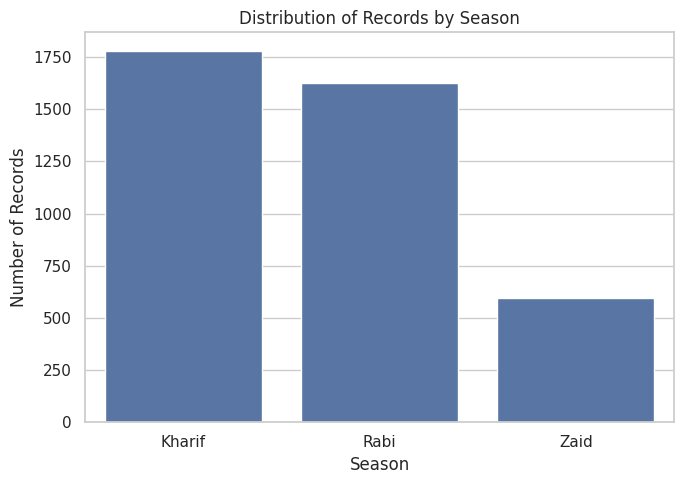

In [26]:
# Univariate: Season distribution
plt. figure (figsize=(7, 5))
sns.countplot(data=df, x="Season" )
plt. title("Distribution of Records by Season")
plt. xlabel ("Season")
plt.ylabel ("Number of Records")
plt. tight_layout ()
plt. show()

<function matplotlib.pyplot.show(close=None, block=None)>

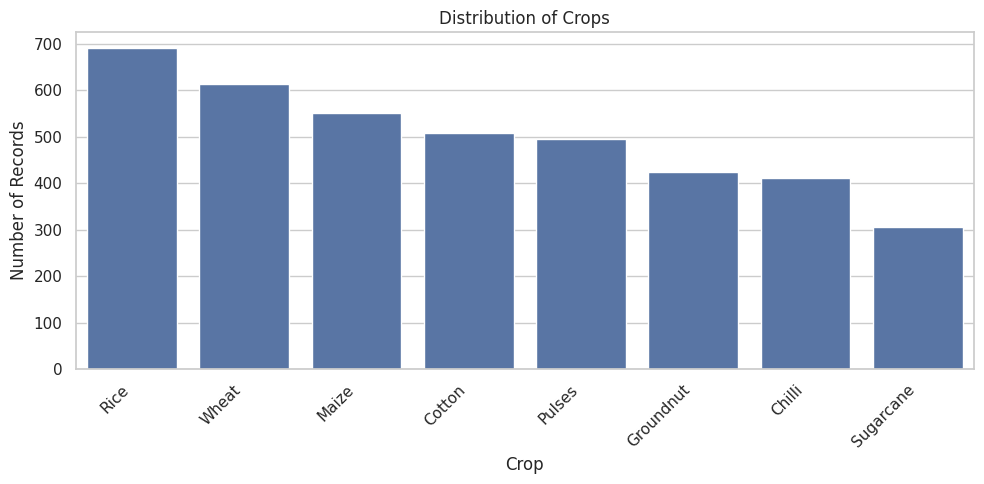

In [27]:
# Univariate: Crop distribution
plt. figure (figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"]. value_counts().index)
plt.xticks(rotation=45, ha="right" )
plt. title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel ("Number of Records")
plt. tight_layout ()
plt. show

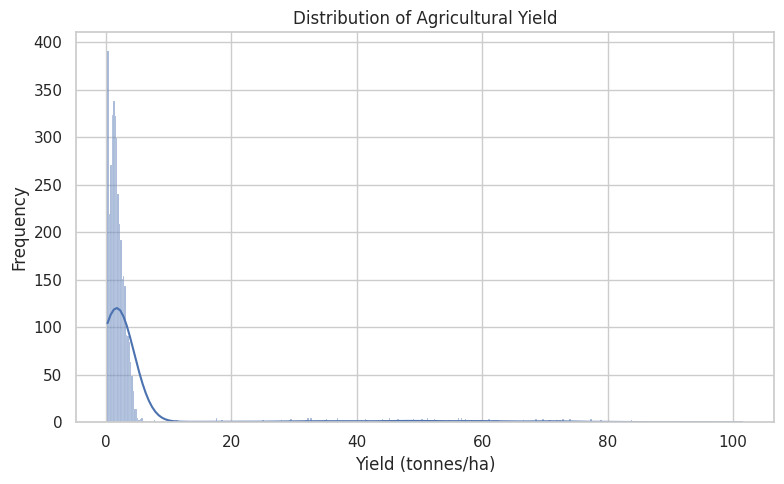

In [28]:
# Univariate: Yield distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt. show()


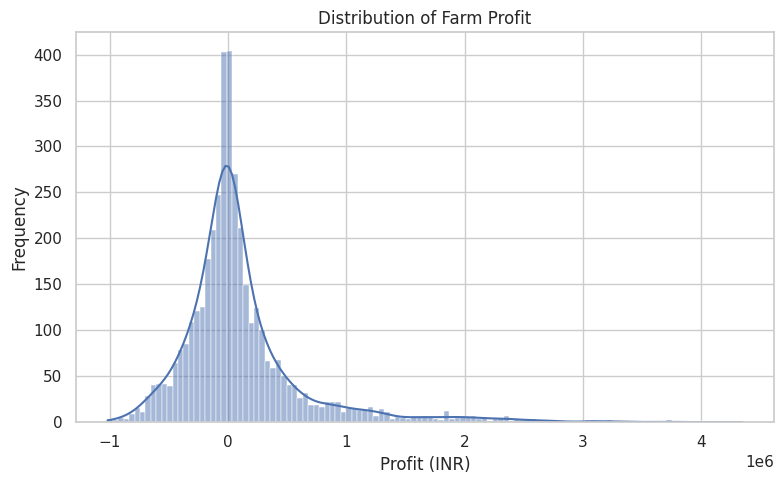

In [29]:
# Univariate: Profit distribution
plt. figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt. title("Distribution of Farm Profit")
plt. xlabel("Profit (INR)")
plt.ylabel ("Frequency")
plt. tight_layout ()
plt. show()

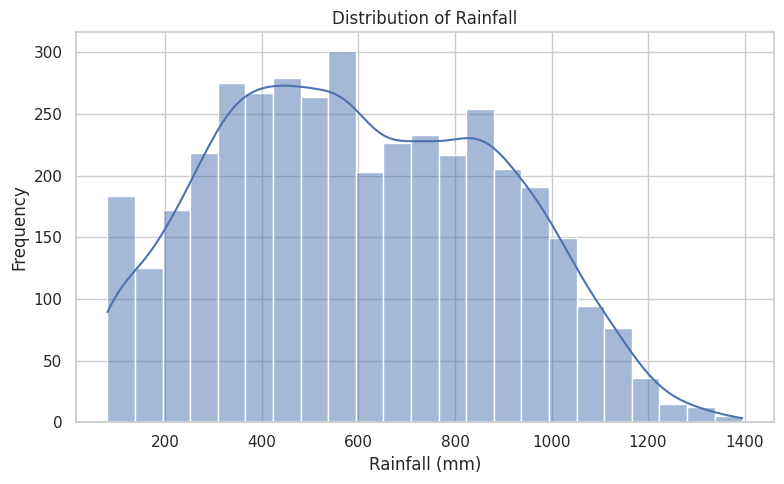

In [30]:
# Univariate: Rainfall distribution
plt. figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel ("Rainfall (mm)")
plt. ylabel ("Frequency")
plt. tight_layout()
plt. show()

# **9. Outlier Analysis**
Identify and analyze outliers in the dataset to detect unusual values, assess their impact, and determine whether they represent errors or meaningful variations.

# Univariate: Season distribution (Pie Chart)

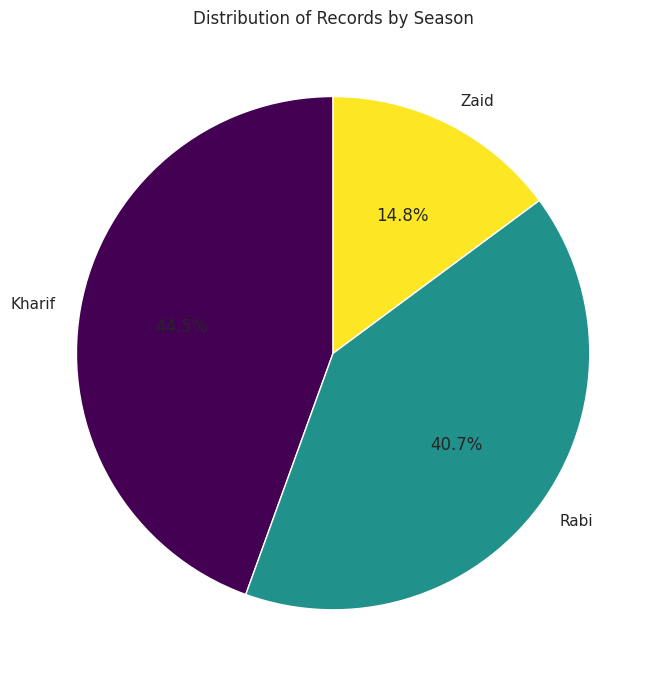

In [31]:
plt. figure(figsize=(7, 7))

df ['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')

plt. title( 'Distribution of Records by Season')

plt.ylabel('')
# Hide the default 'Season' label on the y-axis
plt. tight_layout ()

plt. show()


# **10. Bivariate Analysis**
Bivariate analysis examines relationships or differences between two variables.

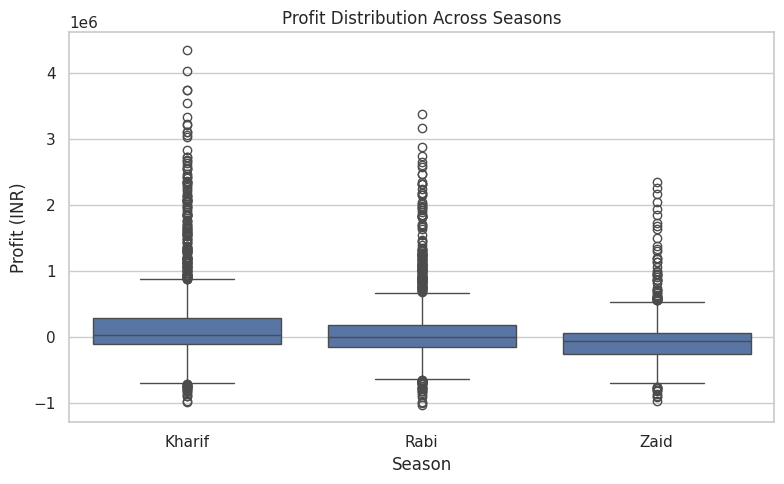

In [32]:
# Bivariate: Season vs Profit
plt. figure(figsize=(8, 5))
sns. boxplot(data=df, x="Season", y="Profit_INR")
plt. title("Profit Distribution Across Seasons")
plt. xlabel ("Season")
plt.ylabel("Profit (INR)")
plt. tight_layout ()
plt. show()

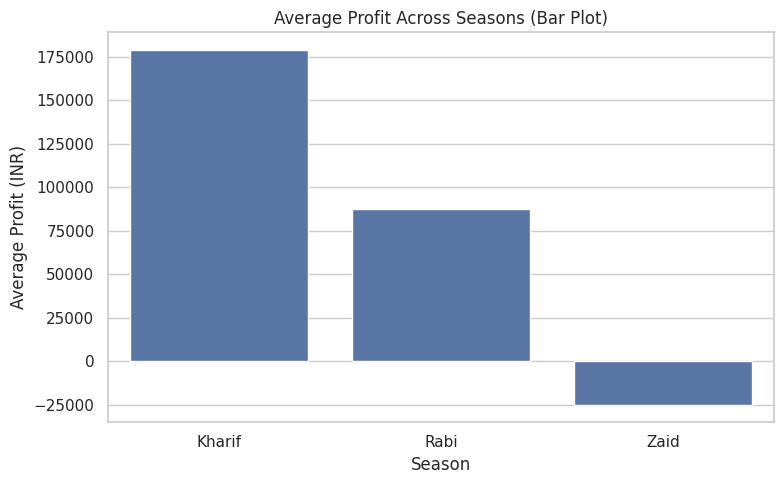

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt. title("Average Profit Across Seasons (Bar Plot)")
plt. xlabel ("Season")
plt. ylabel ("Average Profit (INR)")
plt. tight_layout ()
plt. show()

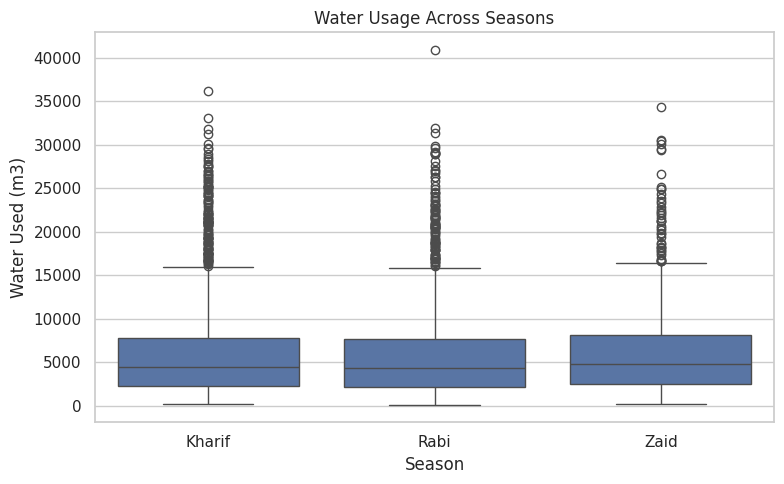

In [34]:
# Bivariate: Season vs Water Usage
plt. figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt. title("Water Usage Across Seasons")
plt. xlabel ("Season" )
plt.ylabel ("Water Used (m3)")
plt. tight_layout()
plt. show()


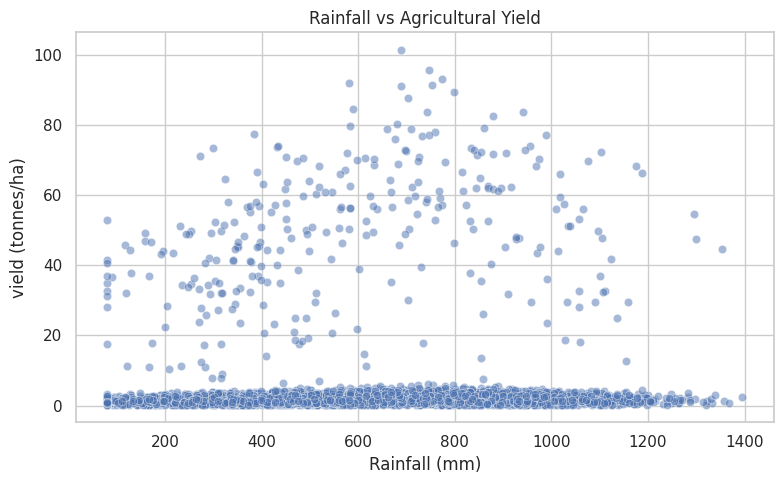

In [35]:
# Bivariate: Rainfall vs Yield
plt. figure (figsize=(8, 5))
sns. scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt. xlabel ("Rainfall (mm)")
plt.ylabel("vield (tonnes/ha)")
plt. tight_layout ()
plt. show()


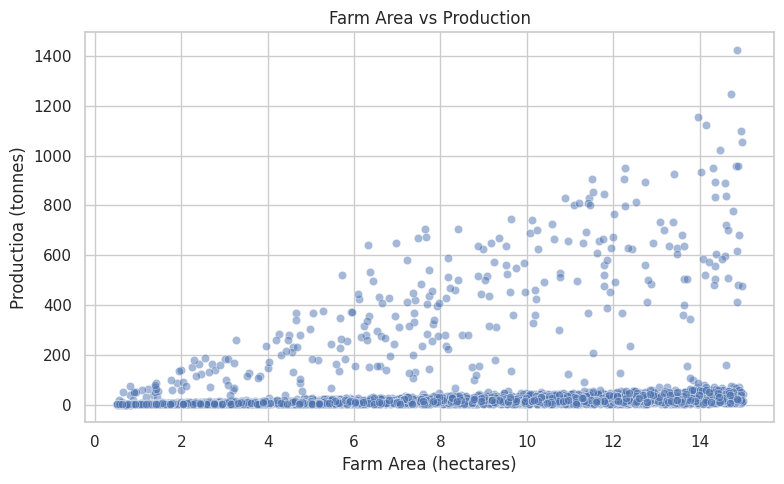

In [36]:
# Bivariate: Farm area vs Production
plt. show( )
plt. figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt. title("Farm Area vs Production")
plt. xlabel("Farm Area (hectares)")
plt.ylabel ("Productioa (tonnes)")
plt. tight_layout()

# **11. Multivariate Analysis**
Multivariate analysis examines multiple variables together to identify how season interacts with factors such as crop, region, environmental conditions, resource usage, and economic performance.

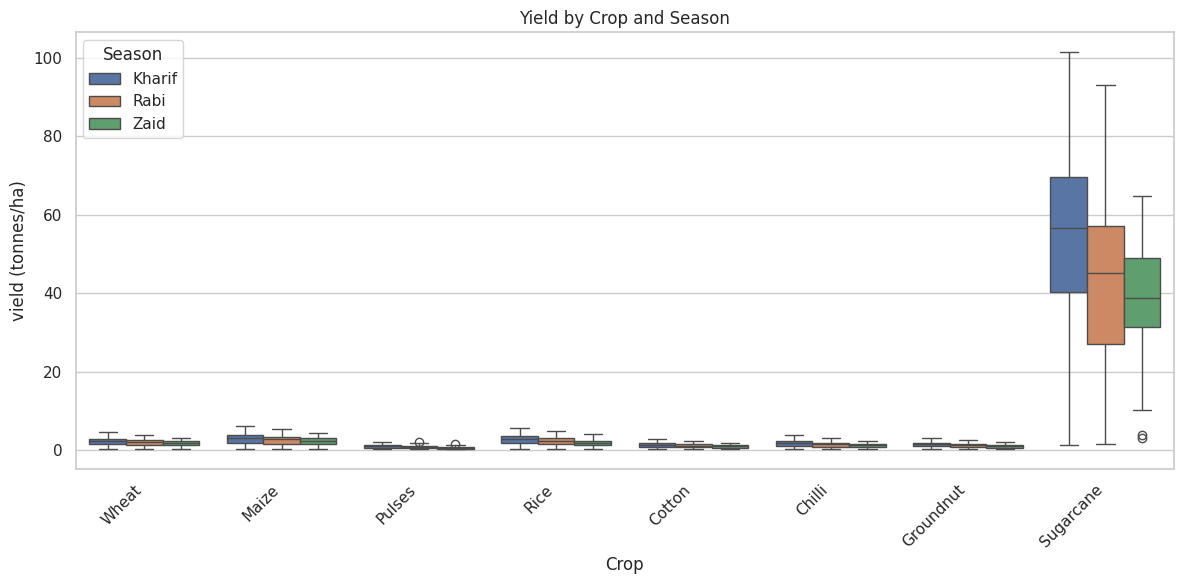

In [37]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks (rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("vield (tonnes/ha)")
plt.legend (title="Season")
plt.tight_layout()
plt.show()

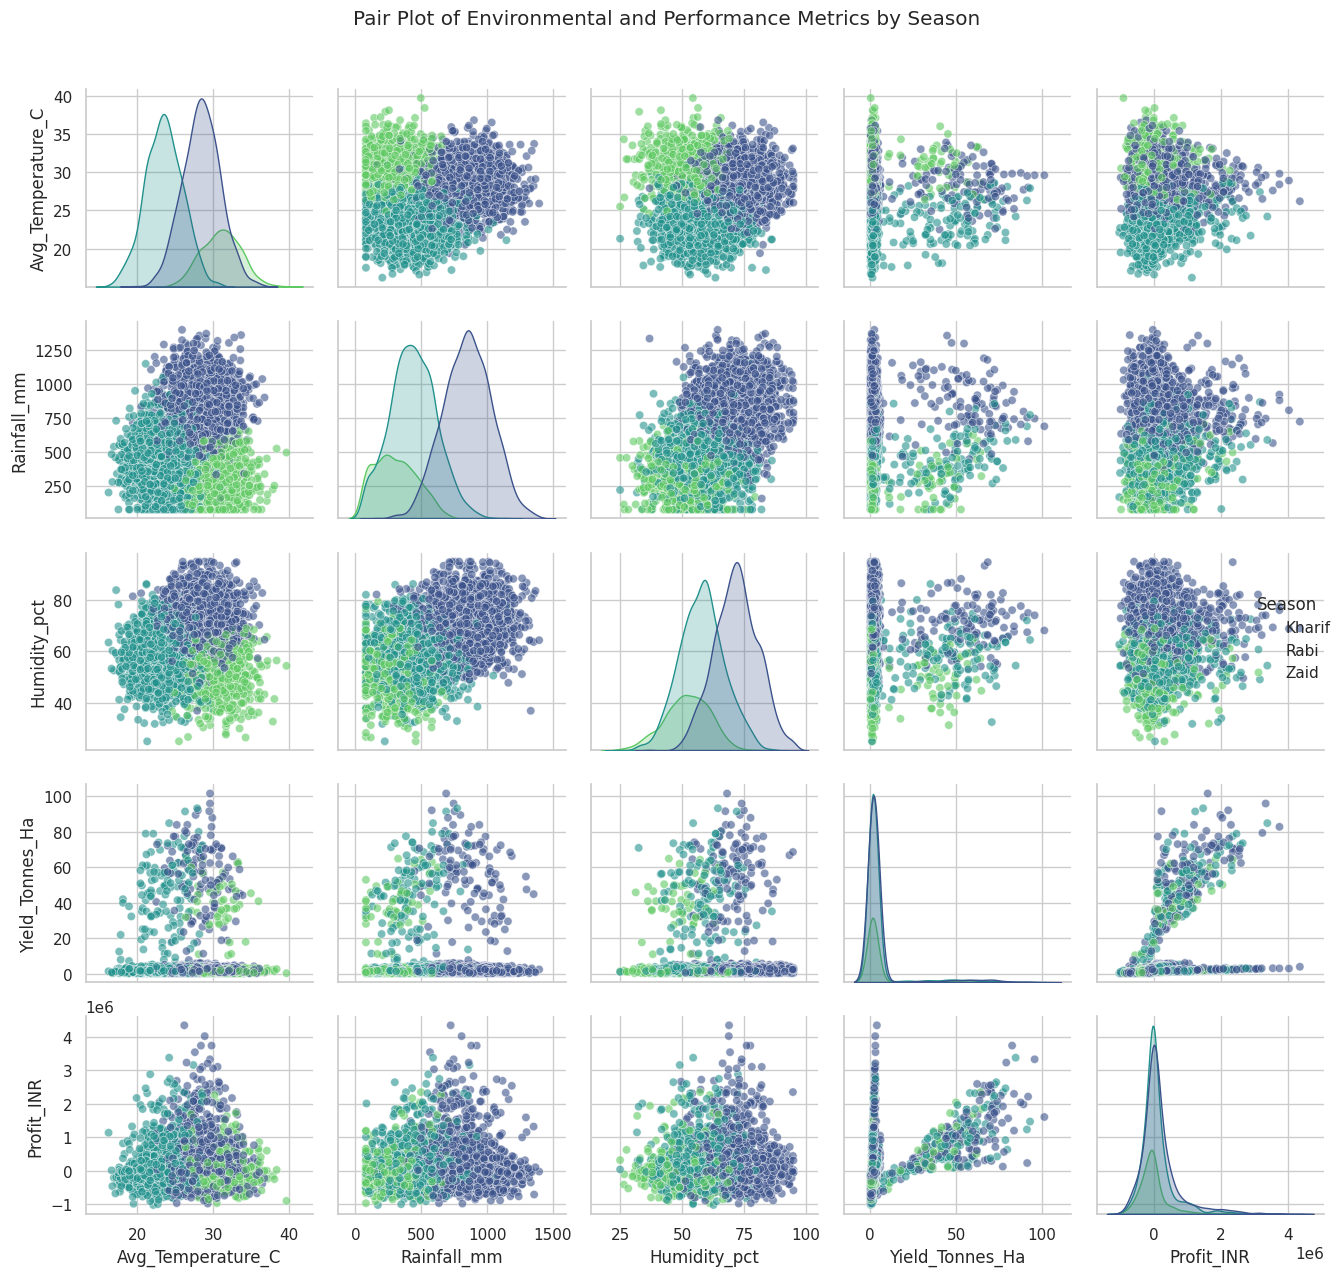

In [43]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR']
sns.pairplot(df, vars=selected_columns, hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

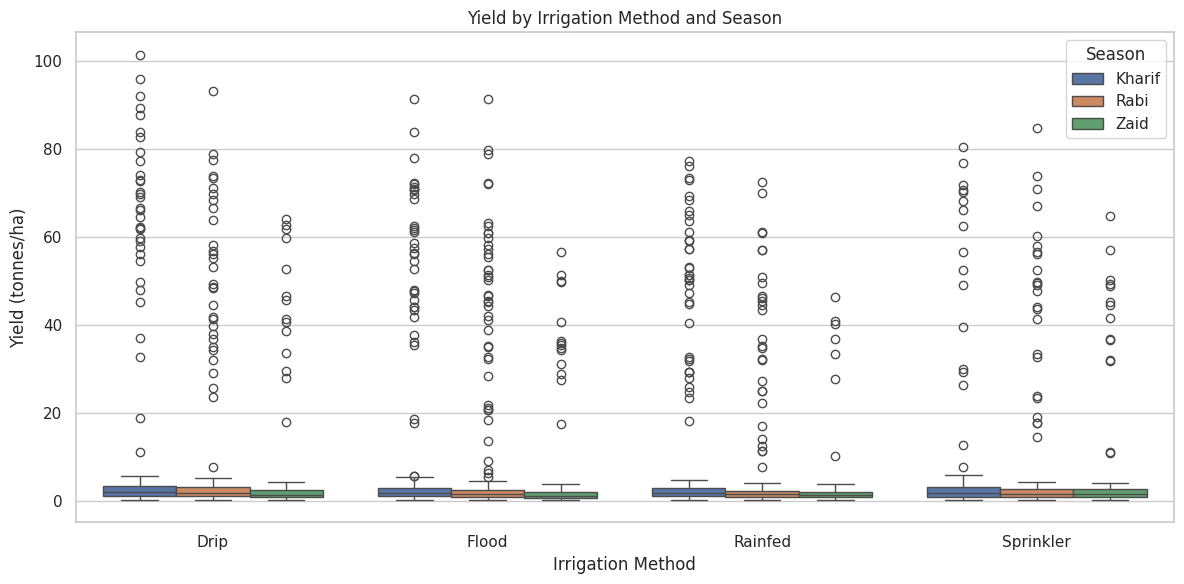

In [44]:
# Multivariate: Season, irrigation and yield
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend (title="Season")
plt.tight_layout()
plt.show()

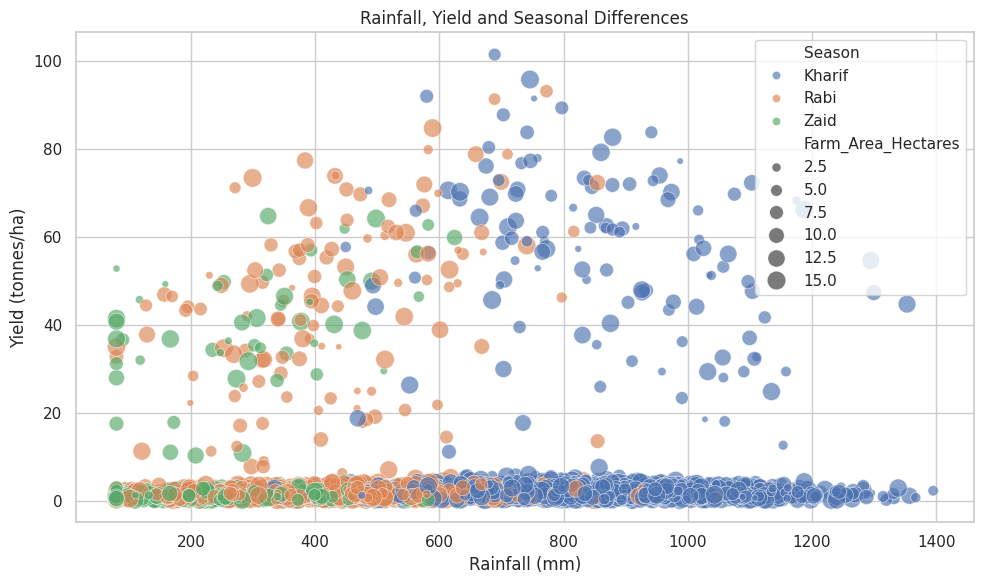

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel ("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

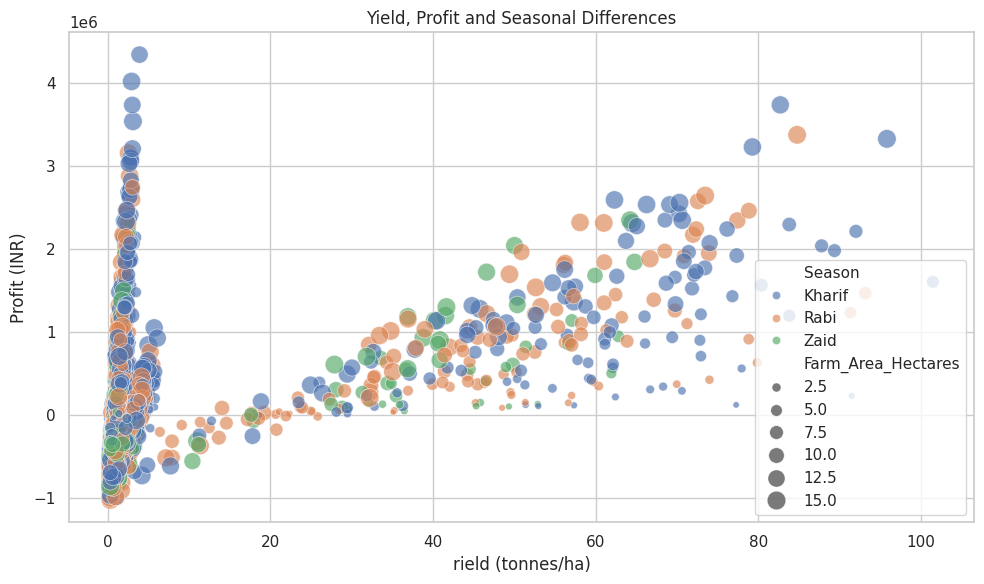

In [52]:
# Multivariate: Profit, yield and season
plt.figure(figsize=(10, 6))
sns.scatterplot(
  data=df,
  x="Yield_Tonnes_Ha",
  y="Profit_INR",
  hue="Season",
  size="Farm_Area_Hectares",
  sizes=(20, 180),
  alpha=0.65)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("rield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

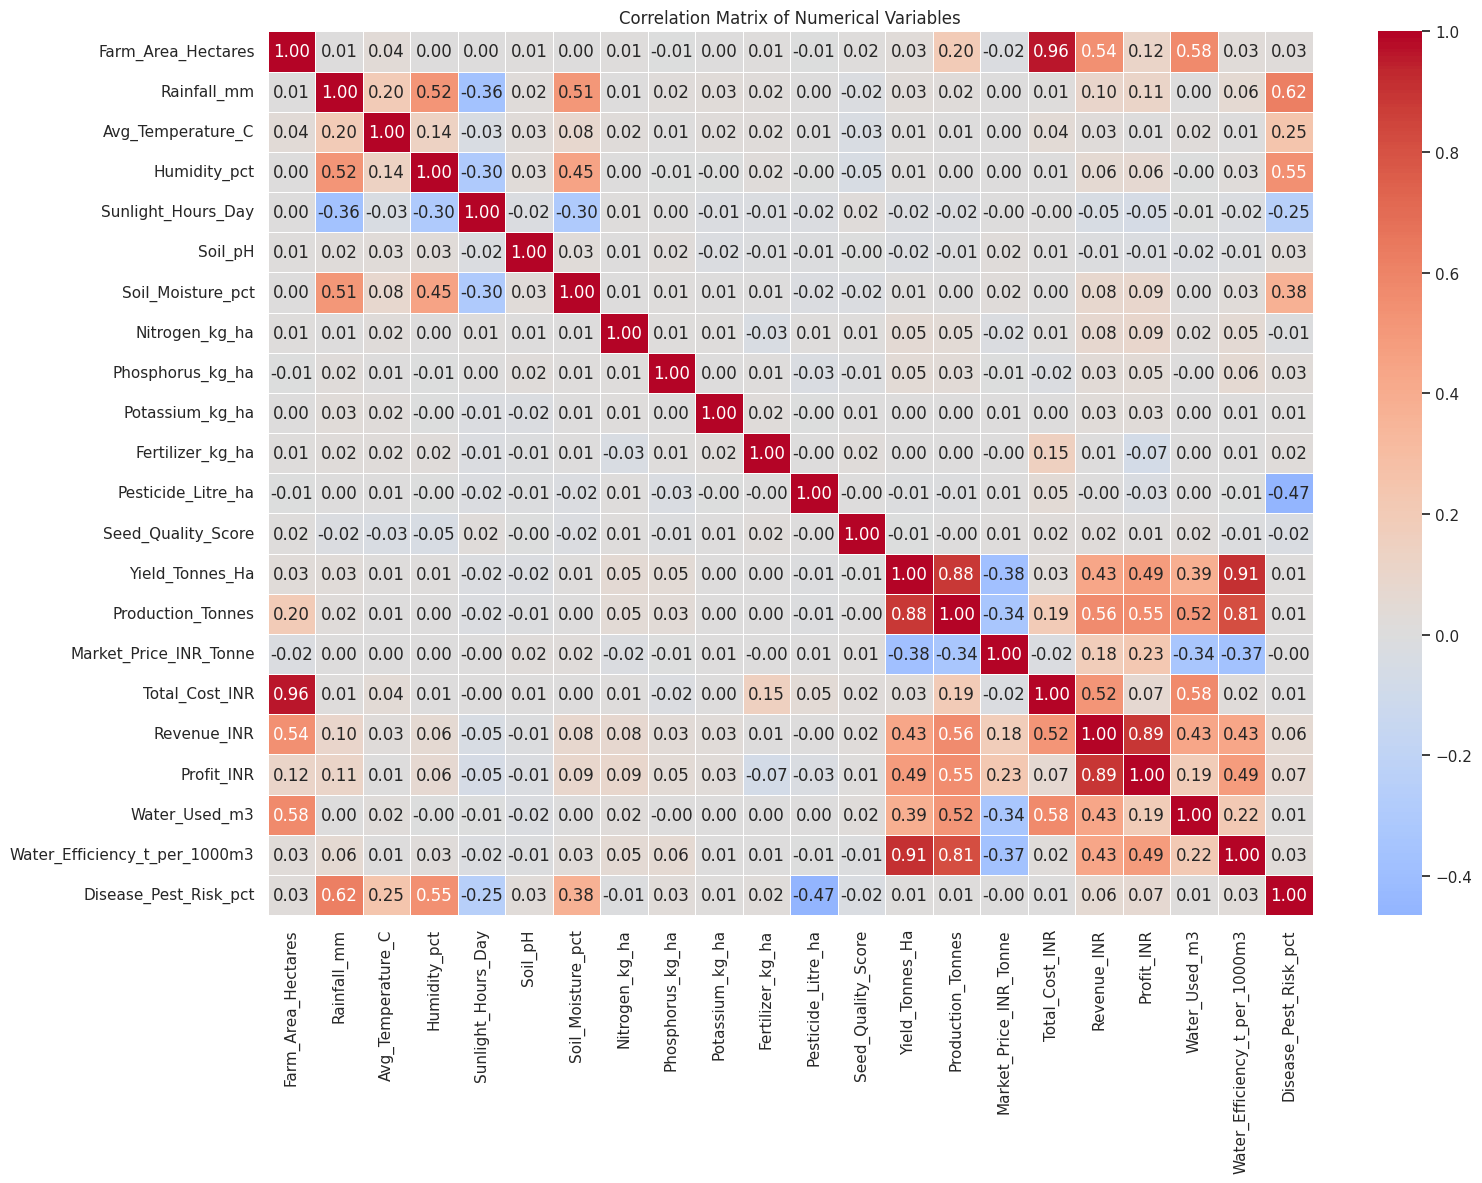

In [56]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
  corr,
  annot=True,
  fmt=".2f",
cmap="coolwarm",
center=0,
linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout ()
plt.show()

# **12. Seasonal Comparison study**
Compare agricultural performance across seasons based on production, resource usage, costs, revenue, and profitability to identify seasonal trends and differences.

In [58]:
# General seasonal summary
season_metrics = df.groupby("Season").agg(
Records=("Farm_ID", "count"),
Average_Yield=("Yield_Tonnes_Ha", "mean"),
Total_Production=("Production_Tonnes","sum"),
Average_Profit=("Profit_INR", "mean"),
Total_Profit=("Profit_INR", "sum"),
Average_Water_Used=("Water_Used_m3", "mean")
).round (2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [61]:
# Compare crop performance within each season
crop_season_summary = (
  df.groupby (["Season", "Crop"])
    .agg(
      Average_Yield=("Yield_Tonnes_Ha", "mean"),
      Average_Profit=("Profit_INR", "mean"),
      Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"))
.round (2)
.sort_values (["Season", "Average_Yield"], ascending=[True, False]))
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

## **13. Additional Student-Driven Analysis**

### 13.1 Regional Differences in Yield per Season

This analysis investigates how 'Yield_Tonnes_Ha' varies across different 'State' for each 'Season'. Understanding regional performance is crucial for identifying areas that excel in certain seasons or crops, and can inform regional agricultural strategies. It's relevant to the project goal of investigating how agricultural performance varies across seasons and identifying meaningful patterns, as regional variations are a significant factor.

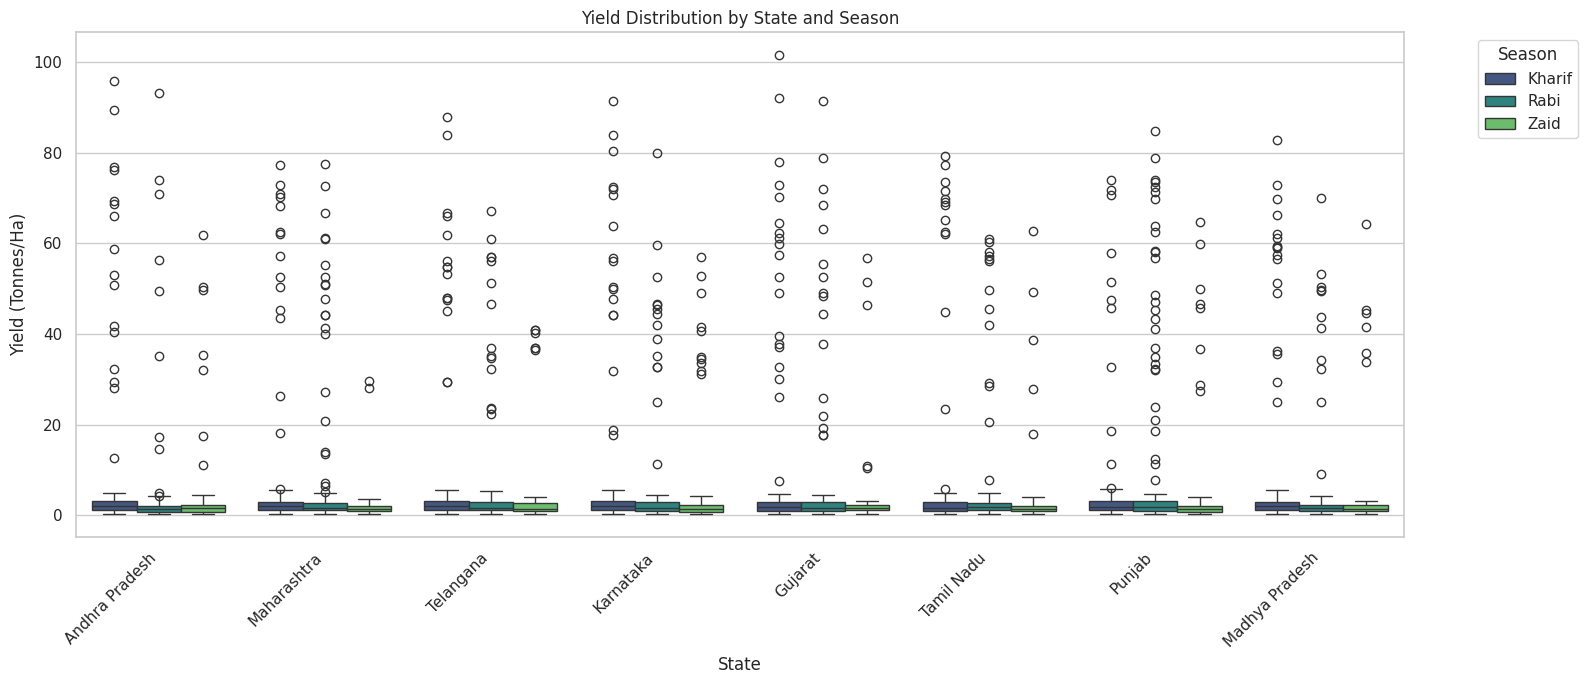

In [62]:
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='State', y='Yield_Tonnes_Ha', hue='Season', palette='viridis')
plt.title('Yield Distribution by State and Season')
plt.xlabel('State')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 13.2 Impact of Soil pH on Yield per Crop

This analysis explores the relationship between soil pH and yield for different crop types. Soil pH is a critical environmental factor affecting nutrient availability and crop growth. Understanding its impact across different crops can help optimize farming practices and improve yield, directly addressing the project objective of investigating relationships among relevant variables and identifying patterns in agricultural performance.

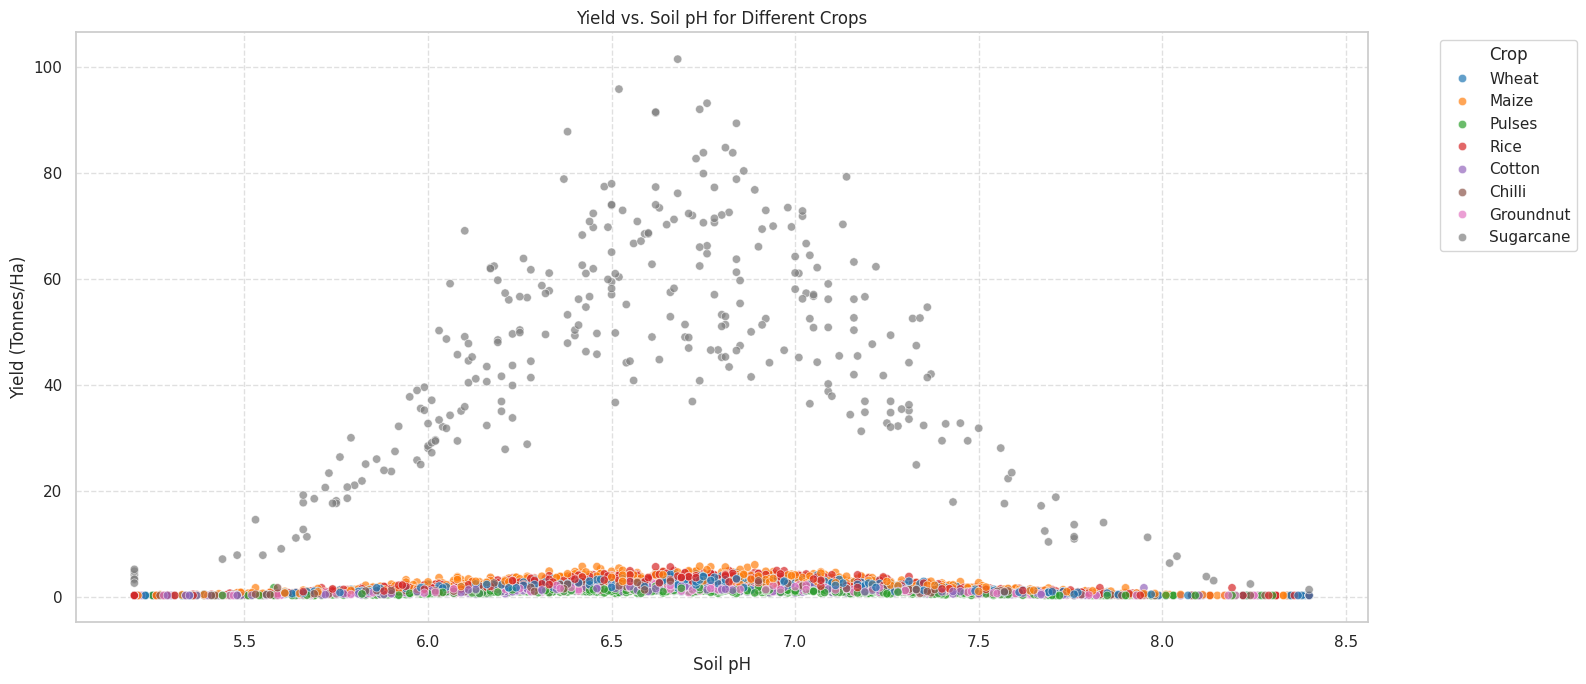

In [63]:
plt.figure(figsize=(16, 7))
sns.scatterplot(data=df, x='Soil_pH', y='Yield_Tonnes_Ha', hue='Crop', palette='tab10', alpha=0.7)
plt.title('Yield vs. Soil pH for Different Crops')
plt.xlabel('Soil pH')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 13.3 Water Efficiency by Irrigation Method and Crop

This analysis focuses on 'Water_Efficiency_t_per_1000m3' across different 'Irrigation_Method' for each 'Crop'. Water usage and efficiency are crucial for sustainable agriculture, especially given seasonal variations in water availability. This analysis directly addresses resource usage, helping to identify efficient practices that can lead to better performance and resource management, aligning with the project's focus on understanding agricultural performance and resource usage.

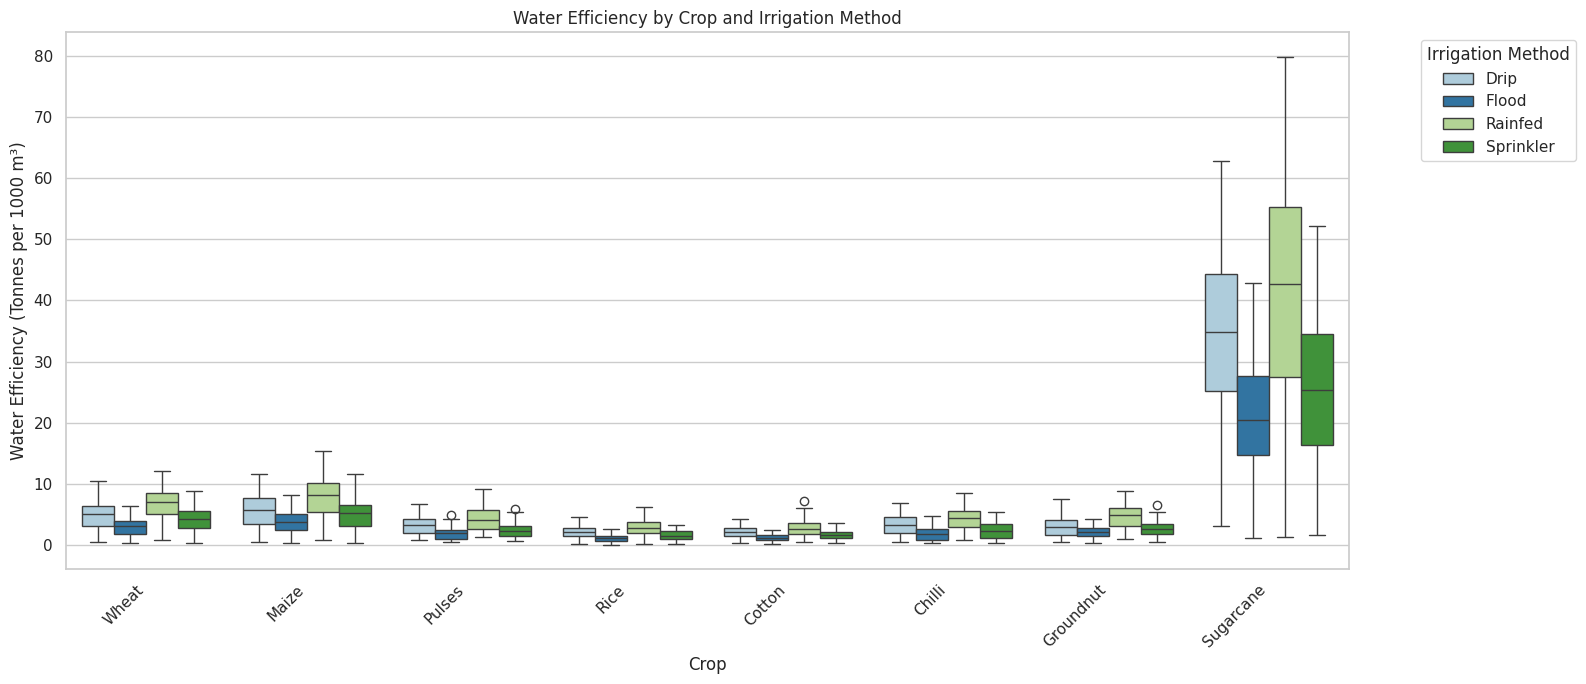

In [64]:
plt.figure(figsize=(16, 7))
sns.boxplot(data=df, x='Crop', y='Water_Efficiency_t_per_1000m3', hue='Irrigation_Method', palette='Paired')
plt.title('Water Efficiency by Crop and Irrigation Method')
plt.xlabel('Crop')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Student Analysis 1

### Question:
How does the market price per tonne affect the profit margin for different crops?

### Analysis:
This analysis investigates the relationship between `Market_Price_INR_Tonne` and `Profit_INR`, segmented by `Crop`. Understanding this relationship is crucial for farmers to make informed decisions about which crops to grow and when to sell, optimizing their economic returns. It directly addresses economic performance patterns within the dataset.

### Visualization:

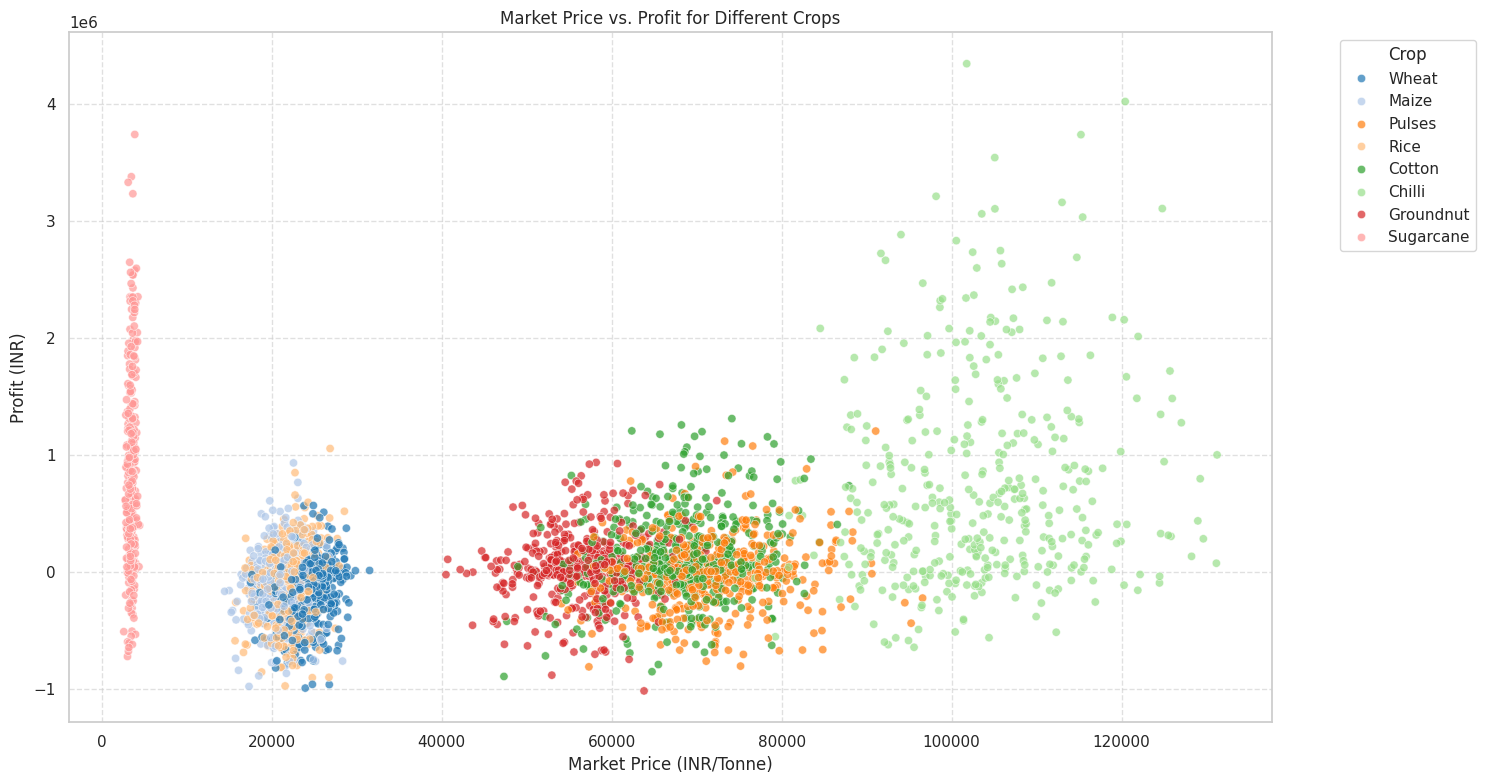

In [65]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='Market_Price_INR_Tonne', y='Profit_INR', hue='Crop', palette='tab20', alpha=0.7)
plt.title('Market Price vs. Profit for Different Crops')
plt.xlabel('Market Price (INR/Tonne)')
plt.ylabel('Profit (INR)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation:
The scatter plot of 'Market_Price_INR_Tonne' vs. 'Profit_INR', colored by 'Crop', reveals varying economic performance across different crop types. Generally, a higher market price per tonne tends to correlate with higher profit margins for most crops, but the slope and spread of this relationship differ significantly. Some crops show a wider range of profits even at similar market prices, suggesting that other factors like cost of production, yield, or farm area also play a crucial role in determining the final profit. For instance, certain high-value crops might consistently yield higher profits, while others might be more volatile. This analysis highlights that simply looking at market price is not sufficient; a holistic view incorporating costs and other factors is essential for maximizing profitability.

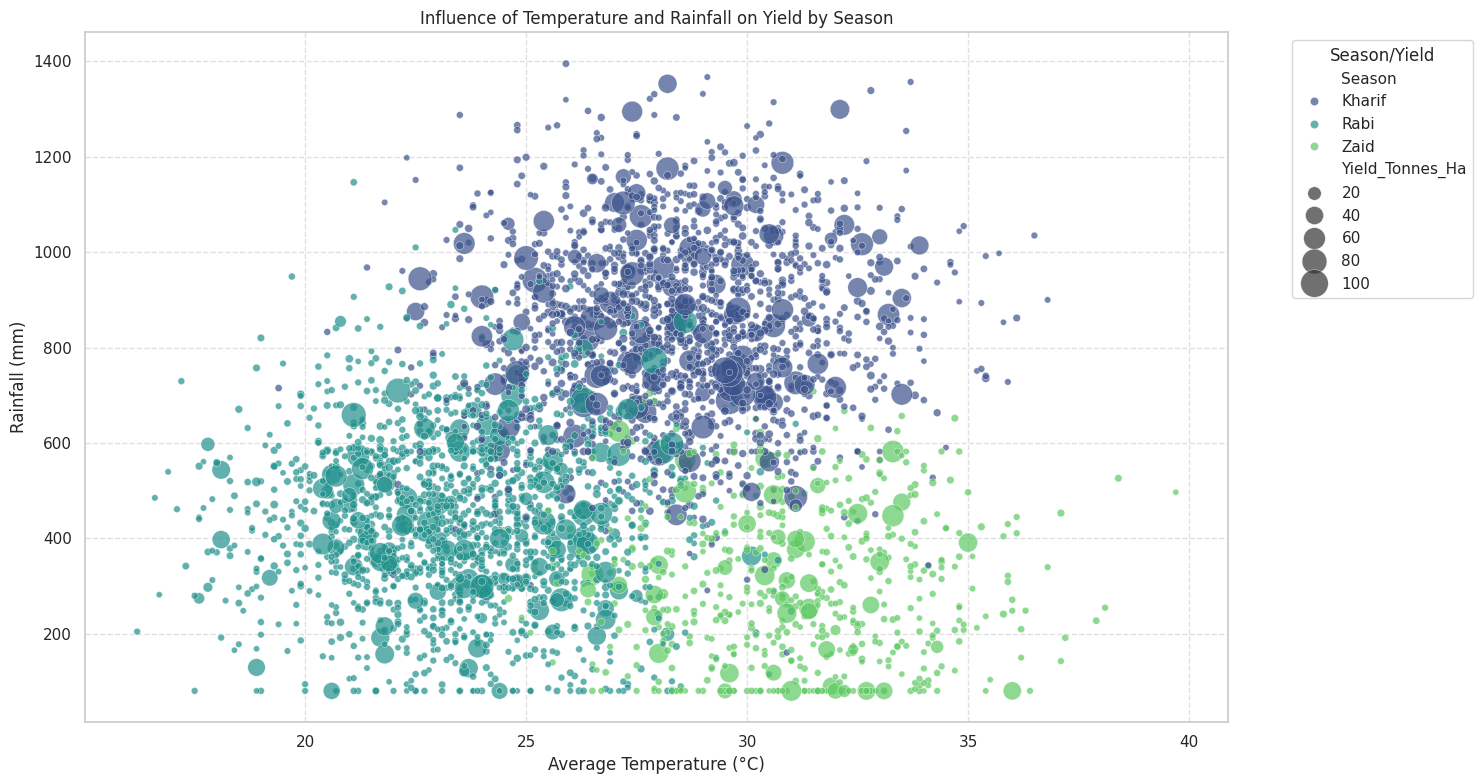

In [66]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Rainfall_mm', hue='Season', size='Yield_Tonnes_Ha', sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Influence of Temperature and Rainfall on Yield by Season')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.legend(title='Season/Yield', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation:
The scatter plot illustrating the influence of 'Avg_Temperature_C' and 'Rainfall_mm' on 'Yield_Tonnes_Ha', with points sized by yield and colored by 'Season', provides insights into optimal environmental conditions. We can observe clusters of high yield (larger points) occurring within specific temperature and rainfall ranges, which vary by season. For example, the Kharif season often shows higher rainfall and moderate-to-high temperatures, supporting higher yields for certain crops. Rabi and Zaid seasons, with typically lower rainfall and different temperature profiles, might favor crops adapted to those conditions or require more irrigation to achieve comparable yields. This visualization helps in identifying the ideal climatic envelopes for maximizing yield in each season.

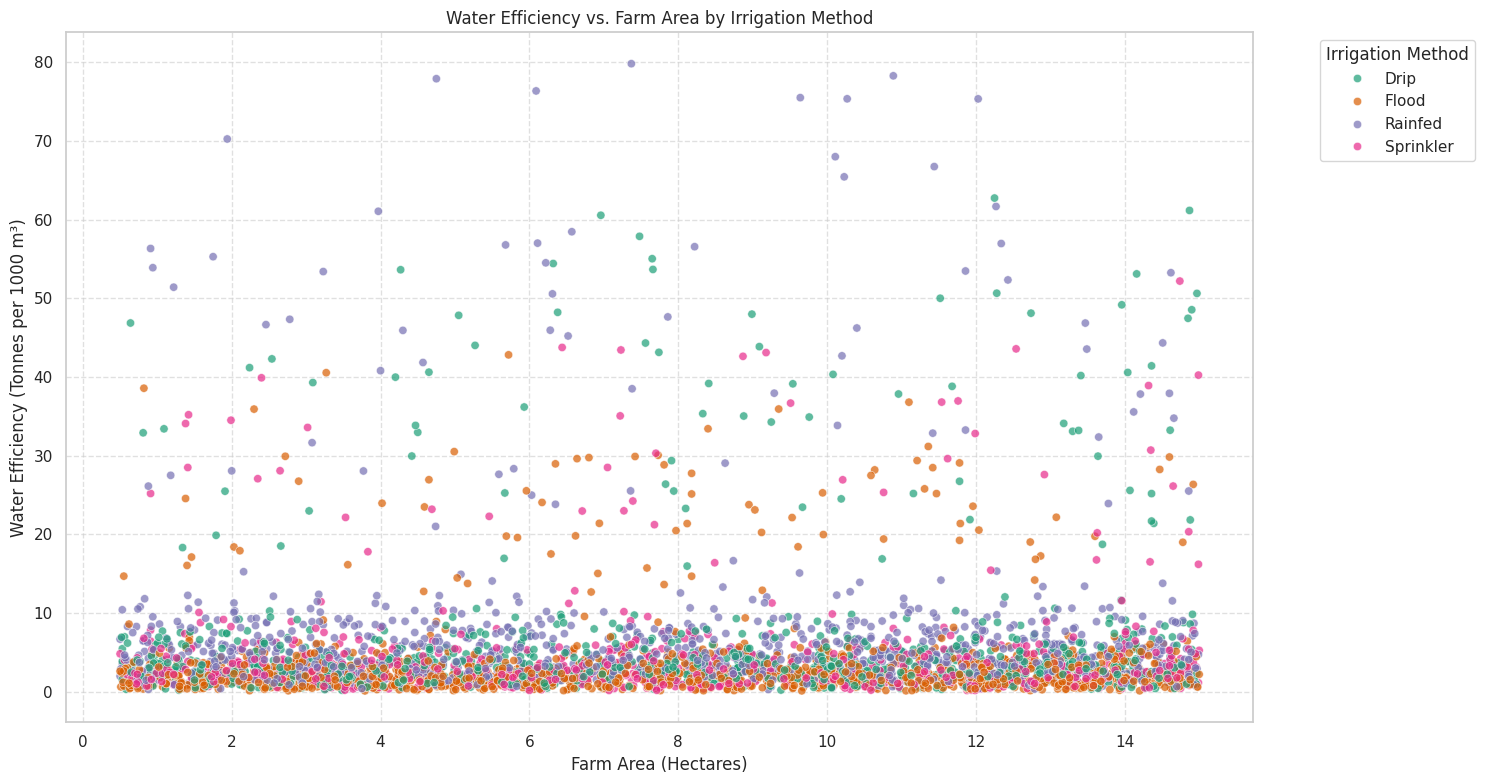

In [67]:
plt.figure(figsize=(15, 8))
sns.scatterplot(data=df, x='Farm_Area_Hectares', y='Water_Efficiency_t_per_1000m3', hue='Irrigation_Method', palette='Dark2', alpha=0.7)
plt.title('Water Efficiency vs. Farm Area by Irrigation Method')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretation:
The scatter plot of 'Farm_Area_Hectares' vs. 'Water_Efficiency_t_per_1000m3', colored by 'Irrigation_Method', helps understand how farm size and irrigation choices impact water usage efficiency. Different irrigation methods (e.g., Drip, Flood, Rainfed, Sprinkler) exhibit distinct patterns of water efficiency, with some methods generally being more efficient than others regardless of farm size. For example, Drip irrigation might show higher efficiency across various farm sizes compared to Flood irrigation. The plot can reveal if larger farms tend to invest in more efficient irrigation systems, or if smaller farms achieve high efficiency through meticulous management. Identifying which irrigation methods perform best for different farm sizes is key for promoting sustainable and resource-efficient agricultural practices.

## 14. Key Insights

Here are some key insights derived from the comprehensive analysis of the seasonal agriculture performance dataset:

### Insight 1: Seasonal Profitability Differences
1.  **Observation**: The Kharif season generally exhibits higher average profits compared to Rabi and Zaid seasons, with Zaid often showing overall losses.
2.  **Evidence**: The 'Seasonal descriptive summary' (Cell `Jxp4NvSDa6rR`) shows mean profits of INR 178,914.65 for Kharif, INR 87,689.47 for Rabi, and INR -24,804.82 for Zaid. Visualizations like the 'Profit Distribution Across Seasons' boxplot (Cell `PA5SzGobfy-9`) and the 'Average Profit Across Seasons' bar plot (Cell `R5YYnlEWfzBj`) further support this.
3.  **Interpretation**: Favorable environmental conditions (e.g., rainfall, temperature), specific crop choices, or market dynamics during the Kharif season appear to be more conducive to generating higher profits for the agricultural practices in this dataset, while the Zaid season presents significant profitability challenges.
4.  **Limitation**: This is a general average; specific crop performance within each season can vary. It does not account for the specific investment costs or risks associated with each season's cultivation practices.

### Insight 2: Sugarcane Dominates in Yield
1.  **Observation**: Sugarcane consistently achieves significantly higher average yields across all seasons compared to any other crop in the dataset.
2.  **Evidence**: The 'Compare crop performance within each season' summary (Cell `Uj7MZolJK74q`) shows Sugarcane yields of 53.46 t/ha (Kharif), 43.29 t/ha (Rabi), and 38.42 t/ha (Zaid). The 'Yield by Crop and Season' boxplot (Cell `nflTNPUyfzK7`) visually confirms this substantial difference.
3.  **Interpretation**: Sugarcane appears to be a high-yielding crop under the observed agricultural conditions, likely due to its biological growth characteristics, optimized cultivation practices, or suitability to the regional climate types represented in the data.
4.  **Limitation**: High yield does not automatically translate to high profitability. Sugarcane might involve higher cultivation costs, longer growth cycles, or specific market demands that affect its net profit per hectare.

### Insight 3: Complex Relationship Between Rainfall and Yield
1.  **Observation**: While there is a general positive association between rainfall and yield, the relationship is not strictly linear and is heavily influenced by the season.
2.  **Evidence**: The 'Rainfall vs Agricultural Yield' scatterplot (Cell `t5tozzELfzF9`) shows a broadly scattered pattern with a slight upward trend. The 'Influence of Temperature and Rainfall on Yield by Season' scatterplot (Cell `9a959b54`) further illustrates distinct optimal rainfall ranges for higher yields across Kharif (higher rainfall tolerance/benefit) compared to Rabi or Zaid.
3.  **Interpretation**: Adequate rainfall is crucial, but yield can be limited by both insufficient and excessive precipitation, with optimal levels varying by seasonal climatic norms and crop requirements. Kharif crops, in particular, appear better adapted to higher rainfall levels.
4.  **Limitation**: This observation indicates association, not causation. Other environmental factors (temperature, soil type, humidity) and agronomic practices interact with rainfall to determine final yield. The specific impact also depends on the crop's water requirements.

### Insight 4: Significant Regional Yield Disparities
1.  **Observation**: Agricultural yield performance exhibits considerable variation across different states and also within states across different seasons.
2.  **Evidence**: The 'Yield Distribution by State and Season' boxplot (Cell `d816ed0c`) clearly displays distinct ranges, medians, and outliers for yield across various states for each season. Some states consistently show higher yields in specific seasons than others.
3.  **Interpretation**: Regional differences in prevailing climatic conditions, soil fertility, predominant farming practices, and crop specialization contribute to varying agricultural productivity levels across different states and periods.
4.  **Limitation**: This analysis does not normalize for the types of crops grown in each state. A state might have lower average yields if it primarily cultivates lower-yielding but high-value crops, or vice-versa.

### Insight 5: Interdependence of Environmental Factors
1.  **Observation**: There are notable positive correlations among key environmental variables such as rainfall, humidity, and average temperature.
2.  **Evidence**: The 'Correlation Matrix of Numerical Variables' heatmap (Cell `P4GUbdZAK7y4`) indicates a moderate positive correlation between 'Rainfall_mm' and 'Humidity_pct' (approx. 0.52), and a weaker but positive correlation between 'Rainfall_mm' and 'Avg_Temperature_C' (approx. 0.20).
3.  **Interpretation**: These correlations reflect natural climatic patterns, where higher rainfall often coincides with increased atmospheric humidity, and both can be associated with specific temperature ranges characteristic of distinct seasons (e.g., monsoon).
4.  **Limitation**: Correlation does not imply causation. While these factors often co-occur, a high correlation does not mean one variable directly causes a change in another; rather, they may all be influenced by broader climatic systems.

### Insight 6: Superior Water Efficiency of Drip Irrigation
1.  **Observation**: Drip irrigation generally demonstrates higher water efficiency (tonnes per 1000 m³) across various crops and farm areas compared to traditional methods like Flood or Rainfed irrigation.
2.  **Evidence**: The 'Water Efficiency by Crop and Irrigation Method' boxplot (Cell `0c68b082`) shows that the median and upper quartiles for Drip irrigation are typically higher. The 'Water Efficiency vs. Farm Area by Irrigation Method' scatterplot (Cell `300c008a`) also positions Drip irrigation points in areas of higher efficiency across different farm sizes.
3.  **Interpretation**: Drip irrigation's method of delivering water directly to the plant root zone minimizes losses due to evaporation, runoff, and deep percolation, leading to a more effective use of water resources and potentially higher yields per unit of water.
4.  **Limitation**: While efficient, drip irrigation often requires a higher initial capital investment for setup and maintenance, which is not captured by the water efficiency metric alone. Its suitability can also depend on crop type and terrain.

### Insight 7: Market Price as a Profit Driver, with Crop Specificity
1.  **Observation**: Higher market prices per tonne generally correlate with increased profit margins, but the sensitivity and absolute profit levels vary significantly among different crops.
2.  **Evidence**: The 'Market Price vs. Profit for Different Crops' scatterplot (Cell `a259c9ce`) shows a general upward trend for most crop clusters. However, some crops achieve high profits at relatively lower market prices (implying high yield or low cost), while others require much higher market prices to become significantly profitable.
3.  **Interpretation**: Market price is a critical determinant of revenue and profit. However, crop-specific characteristics such as production costs, inherent yield potential, and demand elasticity play crucial roles in shaping the ultimate profitability profile of each crop.
4.  **Limitation**: This analysis focuses on price per tonne. Total profit also depends on the total production volume. A crop with a lower market price but significantly higher production could yield greater total profit than a high-priced, low-volume crop.

### Insight 8: Direct Relationship Between Farm Area and Production
1.  **Observation**: There is a strong positive correlation between 'Farm_Area_Hectares' and 'Production_Tonnes'.
2.  **Evidence**: The 'Farm Area vs Production' scatterplot (Cell `4Uy-ZApRfzIk`) clearly illustrates a strong, nearly linear positive relationship, where larger farm areas correspond to higher total production. The correlation matrix would show a high positive coefficient for these two variables.
3.  **Interpretation**: As expected, larger agricultural land areas typically allow for the cultivation of more crops, directly leading to higher overall tonnage produced.
4.  **Limitation**: This observation reflects total production but does not necessarily indicate efficiency. A larger farm might not always have a higher yield per hectare compared to a smaller, more intensively managed farm. It also doesn't account for diversified farming on larger areas.

## 15. Recommendations

Based on the evidence found in the dataset, here are some practical and data-driven recommendations:

### Recommendation 1: Prioritize Kharif Season Investments
*   **Connection to Finding**: The Kharif season consistently shows the highest average profits (Insight 1).
*   **Recommendation**: Farmers should strategically allocate more resources (e.g., better seeds, optimal fertilizers, targeted pest control) and attention to Kharif season crops, given its higher profitability potential. This could involve investing in crops that perform exceptionally well in Kharif.
*   **Limitation**: This recommendation is based on average profits; individual farm conditions and specific crop choices within Kharif need further evaluation for tailored investment strategies.

### Recommendation 2: Optimize Crop Selection for Zaid Season
*   **Connection to Finding**: The Zaid season often incurs overall losses (Insight 1) and generally has lower yields (Seasonal summary `Jxp4NvSDa6rR`).
*   **Recommendation**: Farmers should critically evaluate current Zaid season practices. This might involve shifting towards more resilient, lower-input, or high-value niche crops specifically adapted to Zaid's unique environmental challenges (lower rainfall, higher temperatures), or considering alternative land uses if profitability remains consistently negative.
*   **Limitation**: The dataset does not provide granular data on specific mitigation strategies or alternative crops that might thrive in Zaid; further research or pilot programs would be needed.

### Recommendation 3: Invest in Drip Irrigation Systems
*   **Connection to Finding**: Drip irrigation consistently demonstrates superior water efficiency across various crops and farm sizes (Insight 6).
*   **Recommendation**: Promote the adoption of drip irrigation systems, especially in regions with water scarcity or for crops with high water requirements. Government subsidies or educational programs could facilitate this transition, leading to more sustainable water use and potentially better yields.
*   **Limitation**: The initial capital cost of installing drip irrigation is not accounted for in this analysis. The economic feasibility needs to be assessed per farm, considering payback periods and long-term savings.

### Recommendation 4: Regional-Specific Crop Planning
*   **Connection to Finding**: Significant regional disparities in yield exist across states and seasons (Insight 4).
*   **Recommendation**: Agricultural policymakers and extension services should develop region- and season-specific crop planning guides. This involves identifying which crops yield best in particular states during specific seasons and promoting those combinations, potentially leading to increased overall productivity.
*   **Limitation**: The analysis shows associations. Deeper local-level studies would be required to understand the causal factors (e.g., specific soil types, microclimates, local expertise) contributing to these regional differences.

### Recommendation 5: Market-Driven Crop Diversification
*   **Connection to Finding**: Market price significantly influences profit, but with varying sensitivities across crops (Insight 7).
*   **Recommendation**: Farmers should consider diversifying their crop portfolio based on market price trends and the specific profit-price sensitivity of different crops. This could involve growing a mix of high-yield/low-price crops for stability and lower-yield/high-price crops for higher potential returns, balancing risk and reward.
*   **Limitation**: Market prices are volatile and influenced by external factors not present in the dataset (e.g., global demand, government policies). Predictions based solely on historical data might not always hold true.

### Recommendation 6: Data-Driven Rainfall Management Strategies
*   **Connection to Finding**: The relationship between rainfall and yield is complex and season-dependent (Insight 3).
*   **Recommendation**: Implement rainfall monitoring and localized weather forecasting systems to inform planting schedules, irrigation decisions, and crop protection measures. For Kharif, strategies for managing potential excess rainfall (drainage) might be as important as managing deficits in drier seasons (supplementary irrigation).
*   **Limitation**: The dataset shows historical rainfall; accurate real-time data and predictive models would be needed for actionable, on-the-ground management decisions. The optimal rainfall thresholds for specific crops are not fully detailed.

## 16. Conclusion

This comprehensive analysis of the seasonal agriculture performance dataset has revealed several critical insights into how agricultural performance varies across different seasons, regions, and practices.

### What the Dataset Revealed:
The dataset provided a rich overview of farm-level agricultural records, detailing environmental conditions, resource usage, farming practices, and economic outcomes across three main seasons (Kharif, Rabi, Zaid). It highlighted the inherent variability and complexity of agricultural systems.

### Most Important Patterns Discovered:
*   **Seasonal Profitability Disparity**: Kharif emerged as the most profitable season, while Zaid consistently faced profitability challenges, indicating fundamental differences in seasonal suitability for current farming practices.
*   **Crop-Specific Performance**: Sugarcane consistently achieved the highest yields, demonstrating its strong performance across all seasons. However, high yield did not always guarantee highest profit.
*   **Environmental Influence**: Rainfall and temperature significantly impact yield, with optimal ranges varying by season. There are also clear correlations between environmental factors like rainfall and humidity.
*   **Resource Efficiency**: Drip irrigation proved to be the most water-efficient method, suggesting a path toward more sustainable water management.

### Most Useful Analytical Findings:
*   The detailed **seasonal summaries** (Cell `Jxp4NvSDa6rR`) providing mean, median, and standard deviation for all numerical metrics per season were invaluable for understanding overall seasonal characteristics.
*   The **crop performance comparison within each season** (Cell `Uj7MZolJK74q`) offered clear guidance on which crops perform best under different seasonal conditions in terms of yield, profit, and water efficiency.
*   The **regional yield distribution analysis** (Cell `d816ed0c`) highlighted specific states and seasons where performance excels or lags, providing a basis for targeted interventions.
*   The **correlation heatmap** (Cell `P4GUbdZAK7y4`) provided a quick overview of relationships between numerical variables, confirming expected interdependencies and highlighting potential areas for deeper investigation.

### Important Limitations of the Analysis:
*   **Associative vs. Causal Relationships**: Most analyses identified associations and correlations, not direct causation. Further controlled experiments or detailed causal inference models would be needed to establish definitive cause-and-effect relationships.
*   **Generalizations**: Findings are based on the provided dataset and may not be universally applicable to all agricultural contexts, regions, or farming scales outside the dataset's scope.
*   **Economic Factors**: The dataset provides market prices and costs but does not detail underlying market dynamics, supply chain issues, or policy impacts that significantly influence profitability.
*   **Missing Data Context**: While missing values were imputed, the reasons for their absence were not known, which could potentially bias certain analyses.

### How the Analysis Could Support Future Investigation or Decision-Making:
This analysis provides a strong foundation for strategic decision-making in agriculture. It can support:
*   **Policy Formulation**: Inform policies related to crop subsidies, irrigation infrastructure development, and regional agricultural development programs.
*   **Farm Management**: Guide farmers in optimizing crop selection, irrigation methods, and resource allocation based on seasonal conditions and regional best practices.
*   **Further Research**: Identify specific areas for deeper scientific inquiry, such as detailed studies on soil-nutrient interactions, climate-resilient crop varieties, or the economic impact of specific farming innovations.
*   **Risk Management**: Help stakeholders understand seasonal vulnerabilities and develop strategies to mitigate risks associated with environmental variability and market fluctuations.